# Analising NiSi XRD data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve

import plotly.graph_objects as go

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
API_KEY = "Nc1dTFzE1dg6gchvs0voTKE07XuuXIKW"


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

### read file

In [38]:
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_9_3_1050C_2min_in-plane_GIXRD_detector_scan.xy"
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_12_5_700C_120s_in-plane_GIXRD_detector_scan.xy"
file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_9_3_1050C_2min_in-plane_GIXRD_detector_scan.xy"
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_12_5_700C_120s_in-plane_GIXRD_detector_scan.xy"

data = pd.read_csv(file_path, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])

filename = os.path.basename(file_path)
name = filename.split("_", 7)[3:7]
name = " ".join(name)
print(name)

print(data.info())

1050C 2min in-plane GIXRD
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Angle      9995 non-null   float64
 1   Intensity  9995 non-null   float64
dtypes: float64(2)
memory usage: 156.3 KB
None


In [41]:
# remove offsett by main Ni2Si peak
# data['Angle'] = data['Angle'] + 1.4319  # 700C
data['Angle'] = data['Angle'] + 0.1919  # 1050C

In [42]:
from processXRD import process_XRD_data

processed_data, peak_angles = process_XRD_data(data, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.1, 'width': 10})

c:\Users\lhage\Documents\VSCode\Master_data\XRD\processXRD.py:17: SparseEfficiencyWarning:

spsolve requires A be CSC or CSR matrix format



### plot basic spectra starting point

C:\Users\lhage\AppData\Local\Temp\ipykernel_21792\2548002416.py:12: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



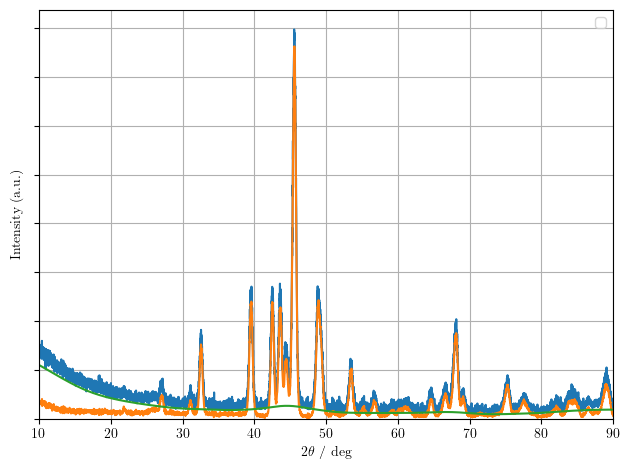

In [44]:
fig, ax = plt.subplots()
ax.plot(data['Angle'], data['Intensity'])
# ax.plot(processed_data['Angle'], processed_data['corrected'])
ax.plot(processed_data['Angle'], processed_data['filtered'])
ax.plot(processed_data['Angle'], processed_data['baseline'])
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(10, 90)
# plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_processed.pdf', dpi=300)
plt.show()

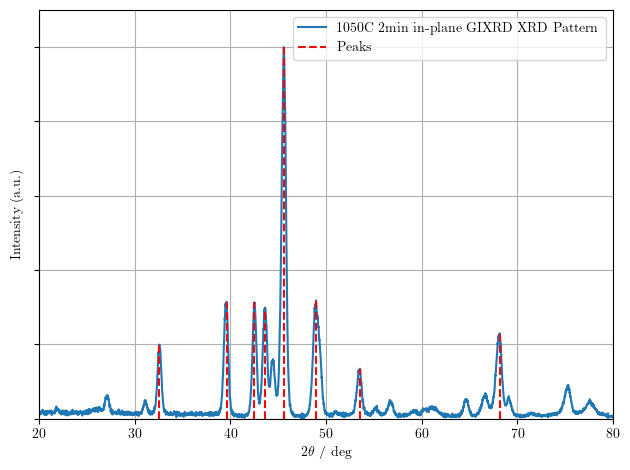

In [45]:
fig, ax = plt.subplots()

ax.plot(processed_data['Angle'], processed_data['intensity_norm'], label=f'{name} XRD Pattern')

plt.vlines(peak_angles.values, ymin=0, ymax=processed_data['intensity_norm'].iloc[peak_angles.index], color='red', linestyle='--', label='Peaks')
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(20, 80)
plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

# expermamenting with auto labeling

In [7]:
def get_clean_reference_with_hkl(material_id, api_key, wavelength=1.5406, intensity_threshold=5):
    """Fetches structure from MP, calculates XRD, and returns 2theta, Intensity, and HKLs."""
    with MPRester(api_key) as mpr:
        docs = mpr.materials.summary.search(material_ids=[material_id], fields=["structure"])
        if not docs:
            raise ValueError(f"No material found for {material_id}")
        structure = docs[0].structure

    calculator = XRDCalculator(wavelength=wavelength)
    pattern = calculator.get_pattern(structure)
    
    x = np.array(pattern.x)
    y = np.array(pattern.y)
    hkl_list = pattern.hkls # Metadata containing Miller indices
    
    # Normalize theoretical intensity to 100
    y = 100 * y / np.max(y)
    
    clean_peaks = {"two_theta": [], "intensity": [], "hkl": []}

    for i in range(len(x)):
        if y[i] >= intensity_threshold:
            clean_peaks["two_theta"].append(x[i])
            clean_peaks["intensity"].append(y[i])
            # Store the first hkl tuple for this peak
            clean_peaks["hkl"].append(hkl_list[i][0]['hkl'])

    return clean_peaks

def auto_label_peaks(exp_peaks, ref_dict, tolerance=0.3):
    """Matches experimental peak positions to the best theoretical phase and HKL."""
    results = [] # Will store strings like "Ni (111)"

    for p_exp in exp_peaks:
        best_match = None
        highest_ref_int = -1
        
        for phase, data in ref_dict.items():
            ref_thetas = np.array(data['two_theta'])
            ref_intensities = np.array(data['intensity'])
            ref_hkls = data['hkl']
            
            diffs = np.abs(ref_thetas - p_exp)
            mask = diffs <= tolerance
            
            if np.any(mask):
                # Find the strongest theoretical peak within the tolerance
                idx = np.where(mask)[0][np.argmax(ref_intensities[mask])]
                current_max_int = ref_intensities[idx]
                
                if current_max_int > highest_ref_int:
                    highest_ref_int = current_max_int
                    hkl = ref_hkls[idx]
                    # Format as Phase (hkl)
                    best_match = f"{phase} ({hkl[0]}{hkl[1]}{hkl[2]})"
        
        results.append(best_match)
    return results

In [8]:
phase_targets = {
    "NiSi2 (Cubic)": "mp-2291",
    "NiSi (Cubic)":  "mp-1095177",
    "NiSi (Ortho)":  "mp-351",
    "Ni2Si (Ortho)": "mp-1118",
    "Ni2Si (Hex)": "mp-507",
    "Ni (Cubic)":    "mp-23",
    "Ni3Si2 (Ortho)": "mp-29667",
    "Ni31Si12 (Trigo)": "mp-27276"
}

# 1. Fetch all reference data
all_references = {}
for name, m_id in phase_targets.items():
    all_references[name] = get_clean_reference_with_hkl(m_id, API_KEY)

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
fig = go.Figure()

# 1. Plot the Experimental Data (the black line)
fig.add_trace(go.Scatter(
    x=processed_data['Angle'], 
    y=processed_data['intensity_norm'],
    mode='lines',
    name='Experimental Data',
    line=dict(color='black', width=1.5)
))

# 2. Add Reference Markers
# We use different colors/symbols for each phase fetched from the API
symbols = ['circle', 'square', 'triangle-up', 'diamond', 'star']

for i, (phase, ref) in enumerate(all_references.items()):
    # We plot these at a fixed height or relative to your data
    # Here, we plot them at y=1.05 (just above the normalized data)
    fig.add_trace(go.Scatter(
        x=ref['two_theta'],
        y=[1.05] * len(ref['two_theta']), # Align them in a row at the top
        mode='markers',
        name=phase,
        marker=dict(symbol=symbols[i % len(symbols)], size=10),
        customdata=list(zip(ref['intensity'], ref['hkl'])),
        hovertemplate=(
        f"<b>{phase}</b><br>"
        "2θ: %{x}<br>"
        "Ref Intensity: %{customdata[0]}%<br>"
        "hkl: %{customdata[1]}"
        "<extra></extra>"
    )
    ))

# 3. Scientific Styling
fig.update_layout(
    yaxis_range=[0, 1.2],
    xaxis_range=[20, 80],
    title="Phase Identification: Nickel Silicides",
    xaxis_title="2θ (degrees)",
    yaxis_title="Intensity (Normalized)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()

In [10]:
phase_styles = {
    "NiSi2 (Cubic)":    {"marker": "D", "color": "#4b0082", "label": r"$NiSi_2$"}, 
    "NiSi (Cubic)":     {"marker": "s", "color": "#27ae60", "label": r"$NiSi$"},     # Square
    "NiSi (Ortho)":     {"marker": "o", "color": "#27ae60", "label": r"$NiSi$"},     # Circle (different!)
    "Ni2Si (Ortho)":    {"marker": "^", "color": "#f1c40f", "label": r"$Ni_2Si$"}, 
    "Ni2Si (Hex)":      {"marker": "v", "color": "#f1c40f", "label": r"$Ni_2Si$"},    # Inverted Triangle
    "Ni (Cubic)":       {"marker": "*", "color": "#2980b9", "label": r"$Ni$"},
    "Ni3Si2 (Ortho)":   {"marker": "P", "color": "#e67e22", "label": r"$Ni_3Si_2$"},
    "Ni31Si12 (Trigo)": {"marker": "X", "color": "#e74c3c", "label": r"$Ni_{31}Si_{12}$"},
    "Unknown":          {"marker": "x", "color": "gray",    "label": "Unknown"}
}

In [31]:
print(peak_angles)
print(labels)

2794    32.4777
3674    39.5177
4036    42.4137
4179    43.5577
4422    45.5017
4844    48.8777
5417    53.4617
7243    68.0697
Name: Angle, dtype: float64
['Ni2Si (Ortho) (111)', 'Ni2Si (Ortho) (112)', 'Ni2Si (Ortho) (013)', 'Ni2Si (Ortho) (120)', 'NiSi (Cubic) (210)', 'Ni2Si (Ortho) (200)', 'Ni3Si2 (Ortho) (004)', 'Ni2Si (Hex) (20-2)']


In [ ]:
manual_labels = {
'$Ni_2Si$': [27.32, 32.8, 39.82, 42.78, 43.92,  3.86], # 43.92
'$NiSi$': [31.28, 49.58, 61.78, 66.98, 75.54], 
'$Ni_3Si_2$': [44.74, 77.58],
'$Ni_{31}Si_{12}$': [57.04, 68.44]
# 'Ni': [44.5]   # 77.62
}

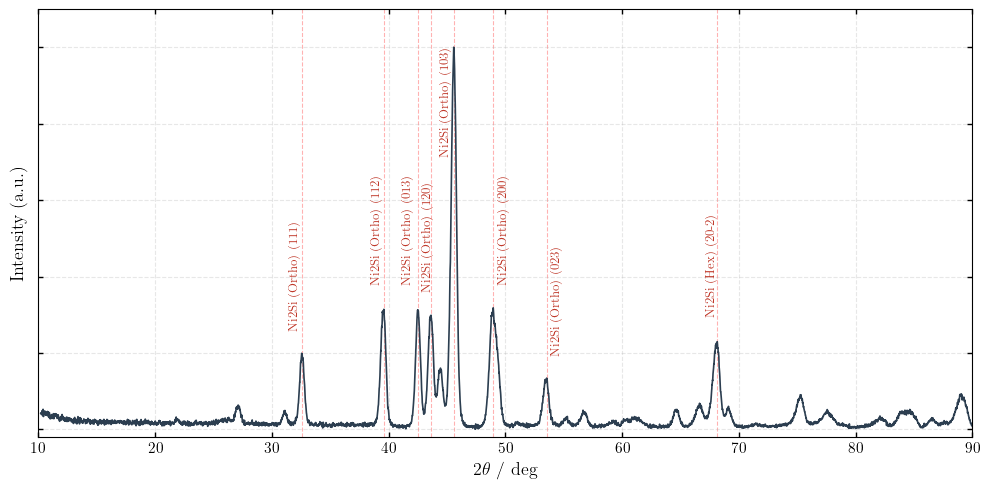

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text  # Make sure to pip install adjust_text

fig, ax = plt.subplots(figsize=(10, 5))

# Plot experimental data
ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
        color='#2c3e50', lw=1.2, zorder=2)

# Identify labels for peaks
labels = auto_label_peaks(peak_angles, all_references, tolerance=0.6)

texts = []
for pos, label in zip(peak_angles, labels):
    if label:
        idx = np.abs(processed_data['Angle'] - pos).argmin()
        peak_height = processed_data['intensity_norm'].iloc[idx]
        
        ax.axvline(pos, color='red', linestyle='--', alpha=0.3, lw=0.8, zorder=1)
        
        t = ax.text(pos, peak_height + 0.02, label, 
                    rotation=90, fontsize=9, 
                    color='#c0392b', weight='bold',
                    va='bottom', ha='center')
        texts.append(t)

adjust_text(texts, 
            only_move={'points':'y', 'text':'xy'}, # Encourage vertical movement first
            add_objects=[ax.lines[0]])              # Avoid overlapping the main XRD line
        #     arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5))


# for lable in final_peaks:
#     angles = final_peaks[lable]
#     y_interp = np.interp(angles, processed_data_900['Angle'].values,  processed_data_900['intensity_norm'].values)    
#     ax.scatter(angles, y_interp+1.5, 
#                 marker=marker_map.get(lable, 'x'),
#                 color=colors[list(final_peaks.keys()).index(lable) % len(colors)],
#                 label=lable,
#                 s=70, edgecolor='black', linewidth=0.6, zorder=5)

ax.set_yticklabels([])
ax.set_xlim(10, 90)
ax.set_ylim(-0.02, 1.1) # Increased upper limit to give labels room to breathe

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

plt.tight_layout()
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_labeled.pdf', dpi=300)
plt.show()